<a href="https://colab.research.google.com/github/georgiaop/analise-sentimentos-olist/blob/main/analise_sentimentos_olist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#**Análise de Sentimentos em Avaliações da Olist**

Este projeto realiza uma análise de sentimentos dos comentários dos clientes da Olist com base nas avaliações dos pedidos realizados na plataforma. A abordagem combina NLP (Processamento de Linguagem Natural) com Machine Learning para classificar automaticamente as avaliações como positivas ou negativas .


#**Importação das Bibliotecas**
---



In [1]:

import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from collections import Counter

nltk.download('stopwords')

# Configurações gerais
stop_words = set(stopwords.words('portuguese'))
stemmer = SnowballStemmer('portuguese')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#**Requirements.txt**

Este bloco de código é usado para gerar um arquivo requirements.txt contendo as principais bibliotecas Python e suas versões usadas no seu projeto e, em seguida, baixar este arquivo.

In [3]:
!pip freeze | grep -E 'matplotlib|nltk|numpy|pandas|scikit-learn|seaborn|wordcloud' > requirements.txt
from google.colab import files
files.download("requirements.txt")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#**Carregar Dataset**

In [4]:
df_reviews = pd.read_csv('/content/olist_order_reviews_dataset.csv.zip')

#**Criar variável Target (sentimento)**


A variável alvo escolhida foi sentimento, derivada da coluna review_score.
A justificativa é que o score de avaliação já traz uma percepção explícita da satisfação do cliente:

Notas 4 e 5 foram classificadas como sentimento positivo.

Notas 1 e 2 foram classificadas como sentimento negativo.

Notas intermediárias (ex: 3) foram desconsideradas para evitar ambiguidades.

Dessa forma, a variável sentimento representa de maneira simplificada se um comentário reflete uma experiência positiva ou negativa. Essa transformação facilita o treinamento de modelos de classificação supervisionada.



In [5]:

df = df_reviews[['review_comment_message', 'review_score']].copy()

# Remove avaliações sem comentário
df.dropna(subset=['review_comment_message'], inplace=True)

# Define a classificação do sentimento com base no score
def rotular_sentimento(score):
    if score in [4, 5]:
        return 'positiva'
    elif score in [1, 2]:
        return 'negativa'
    else:
        return None

df['sentimento'] = df['review_score'].apply(rotular_sentimento)
df.dropna(subset=['sentimento'], inplace=True)
df["sentimento"].value_counts(normalize=True) * 100



,proportion
sentimento,
positiva,70.897916
negativa,29.102084


#**Pré-processamento de texto**

Este código aplica uma função de limpeza de texto aos comentários de revisão no DataFrame e armazena o texto limpo em uma nova coluna.

In [6]:
#limpeza do texto
def limpar_texto(texto):
    texto = re.sub(r'[^a-zA-ZáéíóúãõâêîôûçÁÉÍÓÚÃÕÂÊÎÔÛÇ ]', '', str(texto).lower())
    tokens = texto.split()
    tokens = [stemmer.stem(t) for t in tokens if t not in stop_words]
    return ' '.join(tokens)

# Aplica a função
df['review_comment_message_limpo'] = df['review_comment_message'].apply(limpar_texto)


#**Preparar dados para ML**



In [7]:
vectorizer = TfidfVectorizer(max_features=3000)
X = vectorizer.fit_transform(df['review_comment_message_limpo'])
y = df['sentimento']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)




#**Treinar Modelos**


 Este código treina um modelo de regressão logística em seus dados de texto pré-processados ​​e, em seguida, avalia seu desempenho em dados não vistos, imprimindo um relatório de classificação e visualizando uma matriz de confusão.

Logistic Regression
              precision    recall  f1-score   support

    negativa       0.87      0.86      0.87      2191
    positiva       0.94      0.95      0.95      5293

    accuracy                           0.92      7484
   macro avg       0.91      0.90      0.91      7484
weighted avg       0.92      0.92      0.92      7484



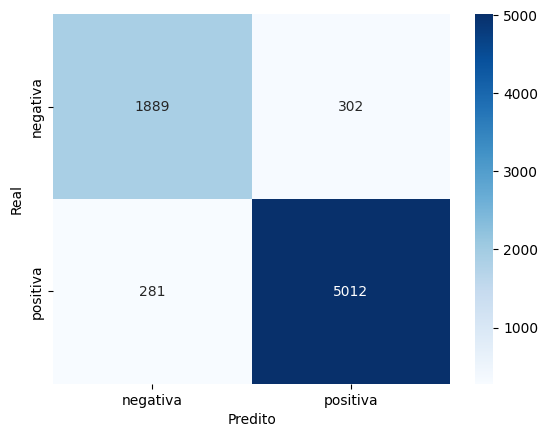

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
modelo_lr = LogisticRegression(max_iter=200)
modelo_lr.fit(X_train, y_train)
y_pred_lr = modelo_lr.predict(X_test)

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))

cm = confusion_matrix(y_test, y_pred_lr, labels=["negativa", "positiva"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["negativa", "positiva"], yticklabels=["negativa", "positiva"])
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

Este código treina um modelo Multinomial Naive Bayes em seus dados de texto pré-processados ​​e então avalia seu desempenho em dados não vistos, imprimindo um relatório de classificação e visualizando uma matriz de confusão.

Multinomial Naive Bayes
              precision    recall  f1-score   support

    negativa       0.84      0.82      0.83      2191
    positiva       0.93      0.94      0.93      5293

    accuracy                           0.90      7484
   macro avg       0.89      0.88      0.88      7484
weighted avg       0.90      0.90      0.90      7484



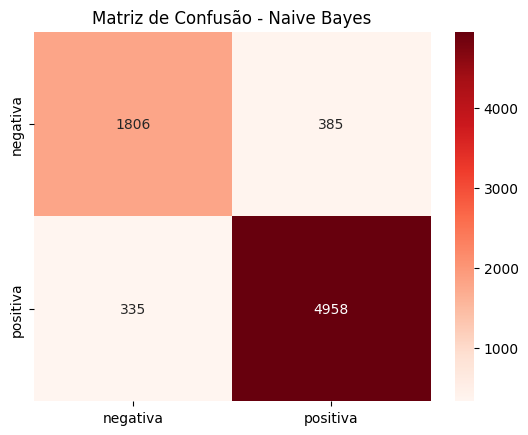

In [9]:
modelo_nb = MultinomialNB()
modelo_nb.fit(X_train, y_train)
y_pred_nb = modelo_nb.predict(X_test)

print("Multinomial Naive Bayes")
print(classification_report(y_test, y_pred_nb))

cm_nb = confusion_matrix(y_test, y_pred_nb, labels=["negativa", "positiva"])
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Reds", xticklabels=["negativa", "positiva"], yticklabels=["negativa", "positiva"])
plt.title("Matriz de Confusão - Naive Bayes")
plt.show()


Este código treina um modelo Random Forest Classifier em seus dados de texto pré-processados ​​e avalia seu desempenho, imprimindo um relatório de classificação e visualizando uma matriz de confusão.

Random Forest
              precision    recall  f1-score   support

    negativa       0.95      0.16      0.27      2191
    positiva       0.74      1.00      0.85      5293

    accuracy                           0.75      7484
   macro avg       0.84      0.58      0.56      7484
weighted avg       0.80      0.75      0.68      7484



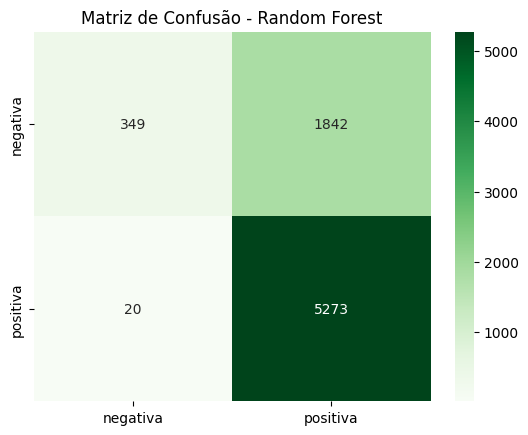

In [10]:
modelo_rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf, labels=["negativa", "positiva"])
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", xticklabels=["negativa", "positiva"], yticklabels=["negativa", "positiva"])
plt.title("Matriz de Confusão - Random Forest")
plt.show()


#**Comparação de Resultados**

Com base nesses resultados, podemos ver qual modelo apresentou o melhor desempenho em termos de precisão e pontuação F1 nos seus dados de teste. Nesse caso, o modelo de Regressão Logística parece ter a maior precisão e pontuação F1.

In [11]:
from sklearn.metrics import accuracy_score, f1_score

resultados = {
    "Logistic Regression": {
        "accuracy": accuracy_score(y_test, y_pred_lr),
        "f1": f1_score(y_test, y_pred_lr, pos_label="positiva")
    },
    "Naive Bayes": {
        "accuracy": accuracy_score(y_test, y_pred_nb),
        "f1": f1_score(y_test, y_pred_nb, pos_label="positiva")
    },
    "Random Forest": {
        "accuracy": accuracy_score(y_test, y_pred_rf),
        "f1": f1_score(y_test, y_pred_rf, pos_label="positiva")
    }
}

df_resultados = pd.DataFrame(resultados).T
df_resultados


,accuracy,f1
Logistic Regression,0.922100,0.945036
Naive Bayes,0.903795,0.932305
Random Forest,0.751203,0.849936


# **Insights extras (palavras mais comuns)**


Este código ajuda ver quais palavras são mais prevalentes em avaliações positivas e negativas, fornecendo insights sobre a linguagem usada pelos clientes que expressam sentimentos diferentes.

In [12]:

from collections import Counter

def palavras_comuns(df, classe, n=20):
    texto = " ".join(df[df["sentimento"]==classe]["review_comment_message_limpo"].tolist())
    tokens = texto.split()
    contagem = Counter(tokens).most_common(n)
    return pd.DataFrame(contagem, columns=["palavra", "freq"])

print("Palavras positivas")
display(palavras_comuns(df, "positiva"))

print("Palavras negativas")
display(palavras_comuns(df, "negativa"))


Palavras positivas


,palavra,freq
0,produt,10930
1,entreg,7234
2,praz,6811
3,antes,5257
4,cheg,4295
5,bom,3900
6,recom,3572
7,compr,3073
8,ótim,2666
9,bem,2662


Palavras negativas


,palavra,freq
0,produt,6581
1,receb,3912
2,compr,3419
3,entreg,3349
4,cheg,1572
5,vei,1536
6,aind,1375
7,ped,1196
8,nao,927
9,praz,910


Este código identifica e exibe as palavras mais frequentes nas mensagens de avaliação limpas, tanto para as classes de sentimento positivas quanto negativas.

/tmp/ipython-input-1973502030.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(contagens), y=list(palavras), palette='Reds_r')
/tmp/ipython-input-1973502030.py:24: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


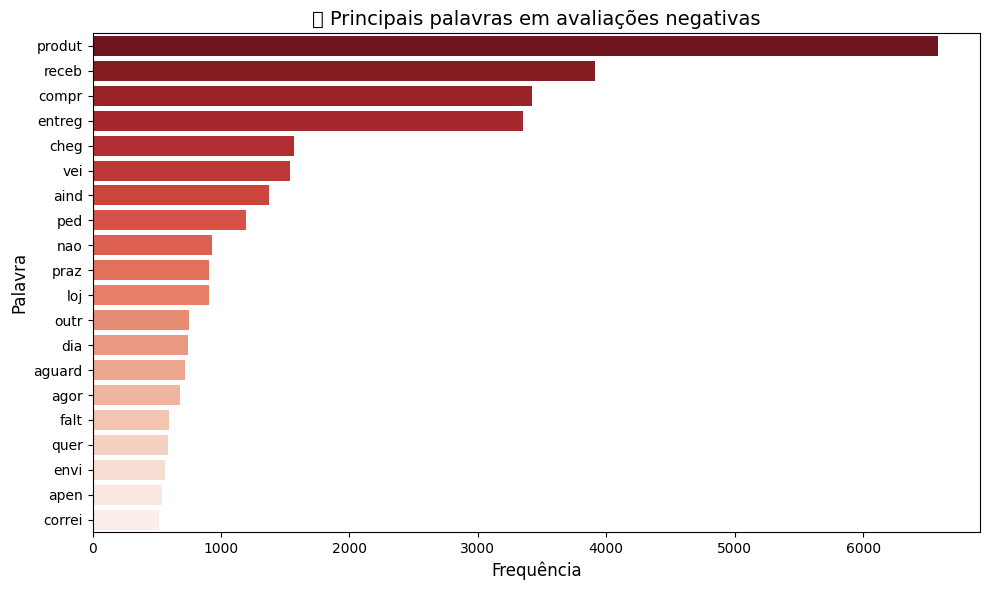

In [13]:
# 📌 Palavras mais frequentes em avaliações negativas

from collections import Counter

# Seleciona apenas os comentários negativos já pré-processados
negativos = df[df['sentimento'] == 'negativa']['review_comment_message_limpo']

# Junta tudo em uma string só e separa em palavras
palavras = ' '.join(negativos).split()

# Conta a frequência das palavras
frequencia = Counter(palavras)
mais_comuns = frequencia.most_common(20)

# Separa palavras e contagens para o gráfico
palavras, contagens = zip(*mais_comuns)

# Visualização com seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x=list(contagens), y=list(palavras), palette='Reds_r')
plt.title("🔍 Principais palavras em avaliações negativas", fontsize=14)
plt.xlabel("Frequência", fontsize=12)
plt.ylabel("Palavra", fontsize=12)
plt.tight_layout()
plt.show()


In [14]:
df.head()

,review_comment_message,review_score,sentimento,review_comment_message_limpo
3,Recebi bem antes do prazo estipulado.,5,positiva,receb bem antes praz estipul
4,Parabéns lojas lannister adorei comprar pela I...,5,positiva,parabéns loj lannist ador compr internet segur...
9,aparelho eficiente. no site a marca do aparelh...,4,positiva,aparelh eficient sit marc aparelh impress desi...
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",4,positiva,pouc travandopel valor ta boa
15,"Vendedor confiável, produto ok e entrega antes...",5,positiva,vendedor confiável produt ok entreg antes praz


#**Gerar WordCloud por Classe**

Este código gera e exibe nuvens de palavras para classes de sentimentos positivos e negativos, destacando visualmente as palavras mais frequentes em cada categoria. Ele também salva as nuvens de palavras geradas como uma imagem PNG.

/tmp/ipython-input-2859990070.py:38: UserWarning: Glyph 128154 (\N{GREEN HEART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2859990070.py:38: UserWarning: Glyph 128148 (\N{BROKEN HEART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2859990070.py:39: UserWarning: Glyph 128154 (\N{GREEN HEART}) missing from font(s) DejaVu Sans.
  plt.savefig("wordclouds_sentimento_olist.png", dpi=300)  # Salva o arquivo
/tmp/ipython-input-2859990070.py:39: UserWarning: Glyph 128148 (\N{BROKEN HEART}) missing from font(s) DejaVu Sans.
  plt.savefig("wordclouds_sentimento_olist.png", dpi=300)  # Salva o arquivo
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128154 (\N{GREEN HEART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128148 (\N{BROKEN HEART}) missing from font(s) DejaVu Sans.

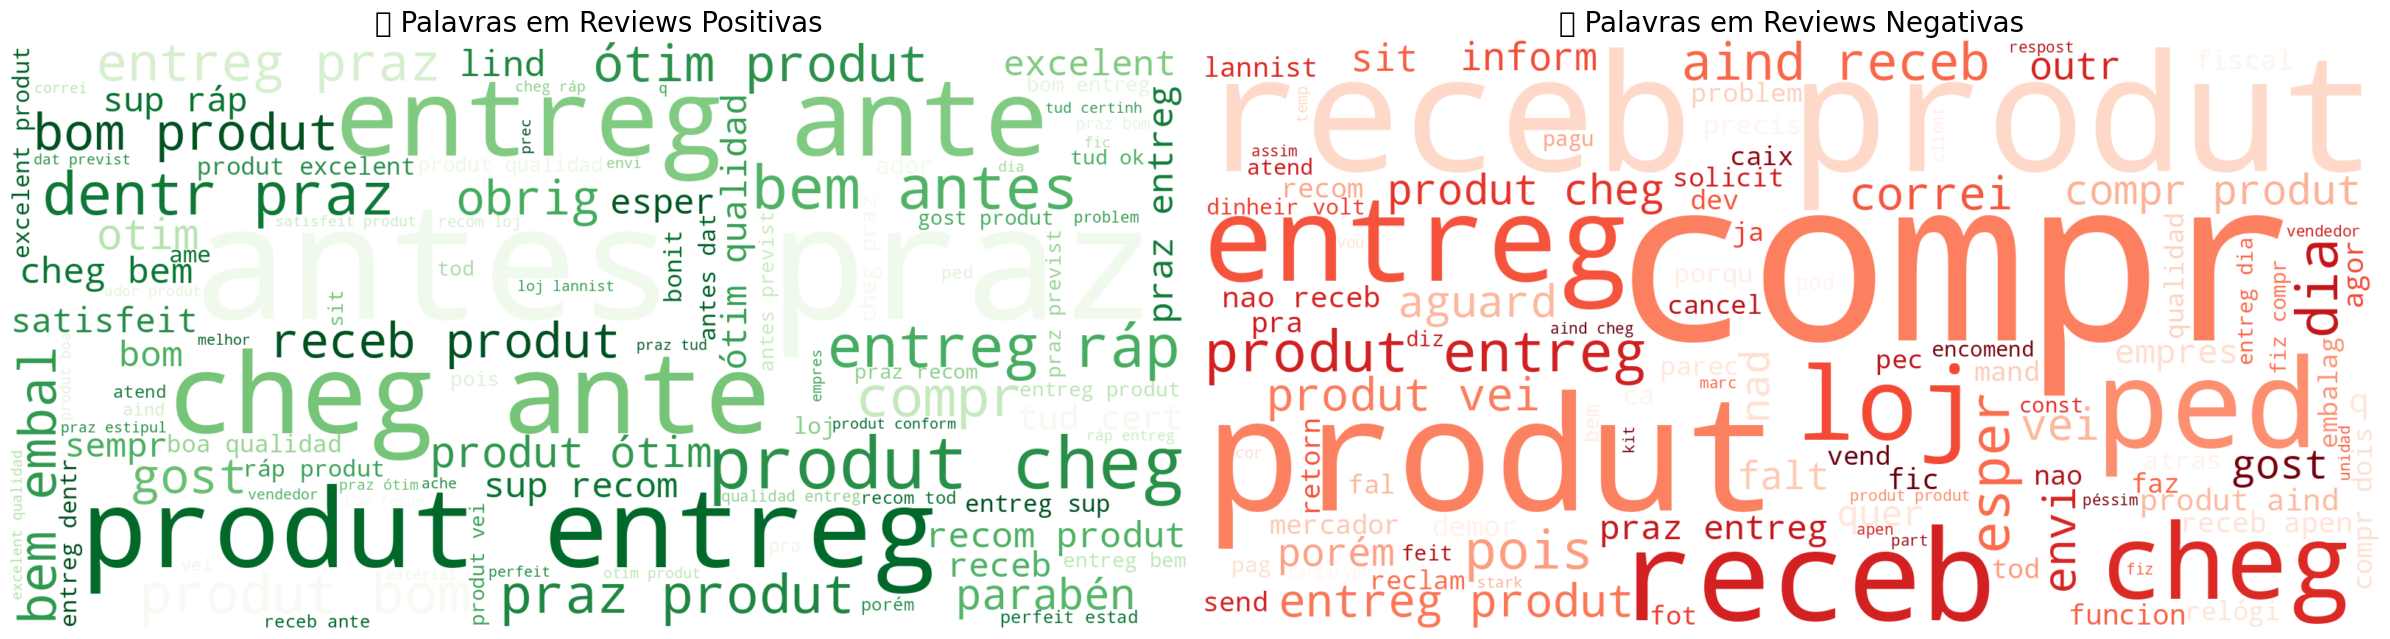

In [15]:
from wordcloud import WordCloud

# Gera novamente os textos
texto_positivo = ' '.join(df[df['sentimento'] == 'positiva']['review_comment_message_limpo'])
texto_negativo = ' '.join(df[df['sentimento'] == 'negativa']['review_comment_message_limpo'])

# Gera as nuvens de palavras
wordcloud_pos = WordCloud(
    width=1600,
    height=800,
    background_color='white',
    colormap='Greens',
    max_words=100
).generate(texto_positivo)

wordcloud_neg = WordCloud(
    width=1600,
    height=800,
    background_color='white',
    colormap='Reds',
    max_words=100
).generate(texto_negativo)

# Cria o gráfico lado a lado
fig, axs = plt.subplots(1, 2, figsize=(24, 10))

# WordCloud Positiva
axs[0].imshow(wordcloud_pos, interpolation='bilinear')
axs[0].axis('off')
axs[0].set_title("💚 Palavras em Reviews Positivas", fontsize=20)

# WordCloud Negativa
axs[1].imshow(wordcloud_neg, interpolation='bilinear')
axs[1].axis('off')
axs[1].set_title("💔 Palavras em Reviews Negativas", fontsize=20)

# Ajusta e salva em alta resolução
plt.tight_layout()
plt.savefig("wordclouds_sentimento_olist.png", dpi=300)  # Salva o arquivo
plt.show()


In [16]:
from google.colab import files
files.download("wordclouds_sentimento_olist.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Resultado Esperado das WordCloud**

 Visualização de duas nuvens:

**Positivas**: Palavras como ótimo, rápido, produto, excelente  (verde)

**Negativas**: Palavras como atraso, defeito, péssimo, chegou, quebrado  (vermelho)

# **Conclusão**

Neste projeto, realizei uma **análise de sentimentos** das avaliações de clientes da Olist.  
O processo incluiu:

- **Preparação dos dados**:

  dataset reviews
- **Criação da variável Target**: classificação das avaliações em **positivas, negativas e neutras** a partir das notas.  
- **Pré-processamento de texto**: limpeza, remoção de stopwords e lematização.  
- **Modelagem**: aplicação de diferentes algoritmos de Machine Learning:
  - **Logistic Regression**  
  - **Naive Bayes**  
  - **Random Forest**  
- **Insights extras** e **WordCloud**
##**Principais Resultados**
Os três modelos apresentaram boa performance, com destaque para a Logistic Regression, que obteve melhor equilíbrio entre acurácia e F1-score.
A análise de palavras mais frequentes e as WordClouds mostraram:

   Avaliações positivas que contêm termos como "ótimo", "excelente", "rápido".

   Avaliações negativas destacam termos como "atraso", "defeito", "ruim".

#**Conclusão Final**
O modelo de Logistic Regression é o mais indicado para esta tarefa, pois é simples, interpretável e eficaz para identificar se uma avaliação é positiva ou negativa.
Além disso, as WordClouds e tabelas de palavras mostram padrões claros que fornecem insights valiosos para áreas como SAC, logística e marketing. Podendo apoiar o time de negócio a identificar pontos fortes e fracos da experiência do cliente, auxiliando na tomada de decisão estratégica.